In [1]:
import random

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [3]:
def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("GPU is not enabled in this notebook. \n"
          "If you want to enable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `GPU` from the dropdown menu")
  else:
    print("GPU is enabled in this notebook. \n"
          "If you want to disable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `None` from the dropdown menu")

  return device


In [4]:
SEED = 2021
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2021 has been set.
GPU is not enabled in this notebook. 
If you want to enable it, in the menu under `Runtime` -> 
`Hardware accelerator.` and select `GPU` from the dropdown menu


In [5]:
#check for gpu
if torch.backends.mps.is_available():
   mps_device = torch.device("mps")
   x = torch.ones(1, device=mps_device)
   print (x)
else:
   print ("MPS device not found.")

MPS device not found.


In [6]:
class Net(nn.Module):
    """
    Initialize MLP Network
    """

    def __init__(self, actv, input_feature_num, hidden_unit_nums, output_feature_num, bias=True):
        """
        Initialize MLP Network parameters

        Args:
            actv: string
                Activation function
            input_feature_num: int
                Number of input features
            hidden_unit_nums: list
                Number of units per hidden layer, list of integers
            output_feature_num: int
                Number of output features

        Returns:
            Nothing
        """

        super(Net, self).__init__()
        self.input_feature_num = input_feature_num
        self.mlp = nn.Sequential()

        in_num = input_feature_num
        for i in np.arange(len(hidden_unit_nums)):
            out_num = hidden_unit_nums[i]
            layer = nn.Linear(in_features=in_num, out_features=out_num, bias=bias)
            in_num = out_num
            self.mlp.add_module(f'Linear_{i}', layer)

            actv_layer = eval(f'nn.{actv}')
            self.mlp.add_module(f'Activation_{i}', actv_layer)

        out_layer = nn.Linear(in_features=in_num, out_features=output_feature_num, bias=bias)
        self.mlp.add_module('Output_Linear', out_layer)


    def forward(self, x):
        """
        Simulate forward pass of MLP Network

        Args:
            x: torch.tensor
                Input data
        
        Returns:
            logits: Instance of MLP
                Forward pass of MLP
        """

        x = x.view(-1, self.input_feature_num)
        logits = self.mlp(x)
        
        return logits

In [7]:
input = torch.zeros((50, 2))
net = Net(actv='LeakyReLU(0.1)', input_feature_num=2, hidden_unit_nums=[100, 10, 5], output_feature_num=3).to(DEVICE)
y = net(input.to(DEVICE))
print(f'The output shape is {y.shape} for an input of shape {input.shape}')

The output shape is torch.Size([50, 3]) for an input of shape torch.Size([50, 2])


In [8]:
DEVICE

'cpu'

## dealing with MNIST dataset

In [3]:
import torchvision
import torchvision.transforms as transforms

batch_size = 4

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [4]:
len(testset)

10000

In [5]:
mean = trainset.data.float().mean()
std = trainset.data.float().std()

tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean / 255.0], std=[std / 255.0])
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform)

# Sample a random subset of 500 indices
subset_index = np.random.choice(len(trainset.data), 1000)
trainset.data = trainset.data[subset_index]
trainset.targets = trainset.targets[subset_index]

subset_index = np.random.choice(len(testset.data), 1000)
testset.data = testset.data[subset_index]
testset.targets = testset.targets[subset_index]

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [6]:
len(trainset), len(testset)

(1000, 1000)

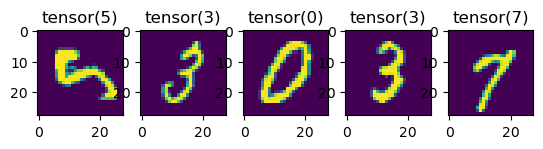

In [7]:
fig, ax = plt.subplots(1, 5)

for i in np.arange(5):
    ax[i].imshow(trainset.data[i])
    ax[i].set_title(trainset.targets[i])

In [8]:
trainset.data.shape
# trainset.targets[0]
trainset.targets

tensor([5, 3, 0, 3, 7, 5, 6, 9, 1, 1, 6, 9, 2, 8, 5, 3, 1, 5, 1, 3, 6, 7, 5, 9,
        8, 9, 8, 4, 9, 5, 0, 5, 8, 4, 7, 4, 5, 3, 4, 7, 6, 7, 4, 6, 6, 9, 1, 7,
        6, 7, 2, 6, 0, 9, 7, 9, 9, 6, 8, 2, 1, 2, 9, 3, 3, 2, 8, 3, 0, 7, 0, 3,
        8, 2, 7, 5, 2, 7, 4, 1, 0, 7, 3, 4, 1, 4, 8, 6, 7, 9, 4, 5, 0, 2, 0, 5,
        9, 1, 0, 0, 3, 3, 8, 1, 7, 7, 3, 8, 4, 8, 6, 8, 5, 1, 8, 6, 0, 7, 6, 5,
        7, 8, 7, 3, 1, 8, 2, 3, 2, 4, 1, 2, 5, 5, 7, 6, 0, 6, 4, 5, 8, 0, 6, 3,
        8, 4, 4, 7, 0, 3, 5, 4, 1, 2, 7, 0, 6, 9, 3, 9, 8, 4, 5, 4, 2, 5, 3, 3,
        9, 5, 0, 3, 4, 5, 9, 9, 6, 1, 1, 1, 2, 3, 4, 9, 5, 5, 2, 9, 7, 2, 8, 2,
        1, 4, 6, 9, 9, 1, 0, 3, 5, 2, 9, 9, 7, 3, 3, 5, 2, 8, 2, 9, 7, 8, 8, 6,
        9, 2, 1, 5, 9, 3, 1, 0, 3, 6, 7, 3, 2, 2, 1, 5, 1, 2, 2, 6, 3, 7, 9, 9,
        5, 2, 5, 7, 6, 4, 9, 1, 3, 8, 4, 1, 5, 8, 5, 0, 6, 6, 2, 2, 6, 9, 4, 5,
        4, 8, 1, 7, 8, 9, 5, 3, 6, 8, 7, 6, 2, 7, 3, 1, 6, 2, 9, 6, 2, 2, 9, 0,
        2, 8, 8, 6, 5, 3, 3, 7, 4, 0, 6,

In [9]:
unique_labels = np.unique(trainset.targets)

In [10]:
# loss function - negative log likelihood
loss_fn = F.nll_loss

In [17]:
def zero_grad(params):
    """
    Clear gradients as they may accumulate on successive backward calls

    Args:
        params: an iterator over tensors
            i.e., updating the weights and biases

    Returns:
        Nothing
    """

    for par in params:
        if not(par.grad is None):
            par.grad.data.zero_()


def gradient_update(loss, params, lr=1e-3):
    """
    Perform a gradient descent update on a given loss over a collection of parameters

    Args:
        loss: Tensor
            A scaler tensor containing the loss through which the gradient will be computed
        params: List of iterables
            Collection of parameters with respect to which we compute gradients
        lr: Float
            Scalar specifying the learning rate or step-size for the update
    
    Returns:
        Nothing
    """

    # Clean up gradients as Pytorch automatically accumulates gradients from successive backward calls

    zero_grad(params)

    # compute gradients on given objects
    loss.backward()

    with torch.no_grad():
        for par in params:
            par.data -= lr * par.grad.data


def print_params(model):
  """
  Lists the name and current value of the model's
  named parameters

  Args:
    model: an nn.Module inherited model
      Represents the ML/DL model

  Returns:
    Nothing
  """
  for name, param in model.named_parameters():
    if param.requires_grad:
      print(name, param.data)

In [18]:
X_train = trainset.data.view(trainset.data.shape[0], -1).float()
y = trainset.targets

In [19]:
net = Net(actv='LeakyReLU(0.1)', input_feature_num=X_train.shape[1], hidden_unit_nums=[20, 30, 20, 10, 5], output_feature_num=len(unique_labels)).to(DEVICE)
# net = Net(actv='Sigmoid()', input_feature_num=X_train.shape[1], hidden_unit_nums=[20, 30, 20, 10, 5], output_feature_num=len(unique_labels)).to(DEVICE)

In [20]:
optimizer = torch.optim.SGD(net.parameters(), lr=1e-2)

n_epochs = 100
criterion = F.nll_loss

In [21]:
def train(model, train_loader, optimizer, criterion):
    model.train()
    for batch_id, (data, target) in enumerate(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        data = data.view(data.shape[0], -1).float()
        y_predicted = net(data.to(DEVICE))
        m = nn.LogSoftmax(dim=1)
        y_predicted = m(y_predicted)

        loss = criterion(y_predicted, target)

        loss.backward()
        optimizer.step()
    return model

def test(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            data = data.view(data.shape[0], -1).float()
            y_predicted = net(data.to(DEVICE))
            m = nn.LogSoftmax(dim=1)
            y_predicted = m(y_predicted)
            test_loss += criterion(y_predicted, target, reduction='sum').item()
            pred = y_predicted.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    
    return test_loss, test_acc

In [22]:
train_loss = []
test_loss = []

train_acc = []
test_acc = []

for epoch in np.arange(n_epochs):
    if np.mod(epoch, 20) == 0:
        print(f'epoch {epoch}')
    net_trained = train(net, trainloader, optimizer, criterion)
        
    # evaluate current model performance on training set and test set
    tr_loss, tr_acc = test(net_trained, trainloader, criterion)
    train_loss.append(tr_loss)
    train_acc.append(tr_acc)
    
    te_loss, te_acc = test(net_trained, testloader, criterion)
    test_loss.append(te_loss)
    test_acc.append(te_acc)

epoch 0
epoch 20
epoch 40
epoch 60
epoch 80


In [23]:
train_loss

[2.2998087272644043,
 2.2655058393478393,
 2.1921565976142885,
 2.0415980944633483,
 1.734368199825287,
 1.5195198662281035,
 1.2722246868610383,
 1.152349614918232,
 1.0061350482106208,
 0.9287523537874222,
 0.8159675006270408,
 0.8105875603854656,
 0.6630689289346338,
 0.6546721096336842,
 0.542864410854876,
 0.5183727175444365,
 0.48193337133806197,
 0.5261509336791933,
 0.3704902470912784,
 0.36399767392501237,
 0.5465292160622776,
 0.284272457851097,
 0.23829518077895046,
 0.17622988146473653,
 0.18422345333057455,
 0.3638062258614227,
 0.10867402592947474,
 0.12967236818699165,
 0.1098199378370773,
 0.08782603322772775,
 0.05656779219093733,
 0.031600062079727646,
 0.02705280090487213,
 0.024422343287529655,
 0.026866738155247732,
 0.02474139410049793,
 0.029925102195626097,
 0.08566039279309916,
 0.15984167191444432,
 0.06501384496039828,
 0.022766001484138543,
 0.02946698296800605,
 0.016799378965051803,
 0.014943896160445547,
 0.01777597727043758,
 0.012185371623589163,
 0.010

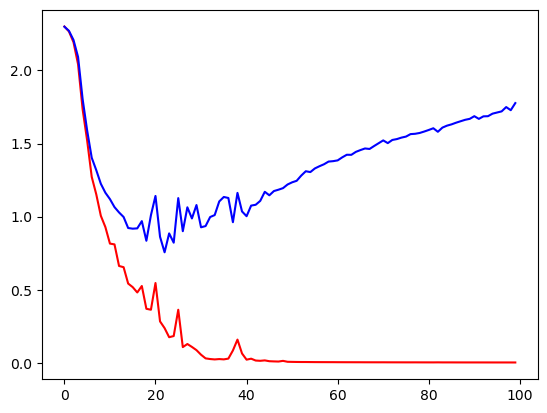

In [24]:
fig, ax = plt.subplots(1, 1)

plt.plot(train_loss, 'r')
plt.plot(test_loss, 'b')

In [25]:
train_acc

[9.3,
 15.6,
 20.6,
 20.6,
 33.9,
 46.3,
 54.3,
 53.8,
 58.5,
 59.6,
 68.3,
 65.9,
 72.3,
 78.4,
 75.9,
 78.5,
 84.7,
 76.1,
 88.8,
 89.3,
 82.2,
 91.3,
 94.3,
 94.4,
 95.1,
 87.8,
 97.7,
 96.0,
 96.7,
 97.9,
 98.9,
 99.6,
 99.6,
 99.6,
 99.4,
 99.5,
 99.5,
 97.1,
 95.6,
 98.3,
 99.7,
 99.4,
 99.6,
 99.7,
 99.8,
 99.8,
 99.7,
 99.7,
 99.7,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.8,
 99.9,
 99.8,
 99.9,
 99.9,
 99.8,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9,
 99.9]

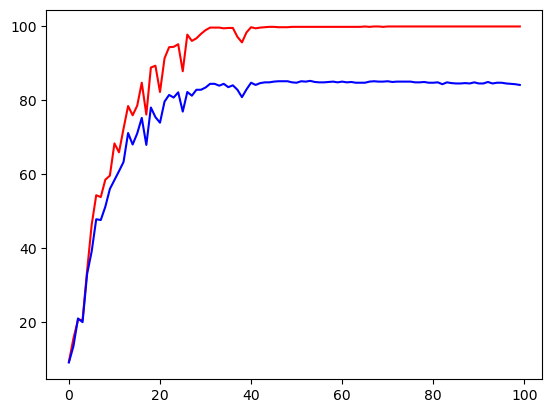

In [26]:
fig, ax = plt.subplots(1, 1)

plt.plot(train_acc, 'r')
plt.plot(test_acc, 'b')